# 03 - Bivariate EDA with Target

            Mục tiêu:

            - Phân tích quan hệ từng feature với target `fraud`.
            - Tính fraud rate, lift theo category/bin.
            - Tìm tín hiệu ban đầu để đưa sang insight mining.

In [1]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: e:\fraud-detection-project


In [2]:
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "data" / "reports"

candidate_paths = [
    INTERIM_DIR / "fraud_cleaned.parquet",
    PROCESSED_DIR / "cleaned_data.parquet",
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raw_csvs = list((PROJECT_ROOT / "data" / "raw").glob("*.csv"))
    if not raw_csvs:
        raise FileNotFoundError("Không tìm thấy dữ liệu cleaned hoặc raw csv.")
    DATA_PATH = raw_csvs[0]

if DATA_PATH.suffix == ".parquet":
    df = pd.read_parquet(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

TARGET_COL = "fraud"
BASE_FRAUD_RATE = df[TARGET_COL].mean()

print("Using:", DATA_PATH)
print("Base fraud rate:", BASE_FRAUD_RATE)
df.head()

Using: e:\fraud-detection-project\data\interim\fraud_cleaned.parquet
Base fraud rate: 0.02549


,amount,currency,local_timestamp,payment_channel,merchant_country,mcc,card_present,ip_risk,device_id,card_entry_mode,auth_result,merchant_id,pin_verif_method,tokenised,recurring_flag,cross_border,card_activation_age,auth_characteristics,message_type,mean_amount_30d,std_amount_30d,max_amount_30d,txn_counts,distinct_merchants_7d,distinct_countries_30d,online_share_7d,night_ratio_30d,days_since_last_txn,decline_rate_30d,chargebacks_365d,device_diversity_30d,mcc_entropy_30d,credit_util_today,spending_trend,term_location,fraud,ip_address,ip_score,txn_count_7d,txn_count_30d,txn_count_ratio_7d_30d,ip_is_private,ip_score_bin,transaction_datetime,hour,day_of_week,day_name,is_weekend,is_night_txn,month,day,year,time_period,night_unusual_score,is_night_unusual,amount_invalid_flag,std_amount_30d_zero_flag,mean_amount_30d_zero_flag,duplicate_row_flag
0,100606.12,USD,2025-03-19 10:23:03,ATM,PH,7736,True,"{'ip': '190.3.86.171', 'score': 0.1467}",DEV-7726FB1A8A274C4B,CHIP,3DS_FAIL,MID-2585C551D674,OFFLINE_PIN,False,MOTO_PHONE,True,4282,FALLBACK_MAG,0110-AuthRsp,5.19,6.62,34046.16,"(13, 21)",112,2,0.210,0.084,100,0.271,3,27,0.801,0.943,1.460,BRANCH_COUNTER,0,190.3.86.171,0.1467,13.0,21.0,0.590909,0,low,2025-03-19 10:23:03,10,2,Wednesday,0,0,3,19,2025,morning,0.000,0,0,0,0,0
1,146953.67,USD,2025-05-16 00:35:42,WEB_BROWSER,GB,3242,False,"{'ip': '79.201.116.230', 'score': 0.5243}",DEV-68CD2988A8C345AC,CHIP,BIOMETRIC_PASS,MID-CA3988467DD9,ONLINE_PIN,True,INSTALLMENT_PLAN,False,3804,CRYPTOGRAM_PRESENT,0110-AuthRsp,6.18,35.50,7146.37,"(22, 256)",3,9,0.665,0.751,177,0.098,3,17,0.651,1.269,4.980,BRANCH_COUNTER,0,79.201.116.230,0.5243,22.0,256.0,0.085603,0,high,2025-05-16 00:35:42,0,4,Friday,0,1,5,16,2025,night,0.249,0,0,0,0,0
2,161096.38,USD,2025-04-10 03:03:24,ATM,US,5638,True,"{'ip': '16.247.34.115', 'score': 0.4811}",DEV-C75EBE4E1BCB4362,TOKEN_IN_APP,CVV_FAIL,MID-9D430F327DF7,OFFLINE_PIN,True,RECURRING_SUBSCRIPTION,False,2292,E_COMMERCE,0110-AuthRsp,5.80,4.32,72447.86,"(13, 29)",40,16,0.322,0.637,34,0.092,0,11,0.646,0.291,4.514,KIOSK,0,16.247.34.115,0.4811,13.0,29.0,0.433333,0,medium,2025-04-10 03:03:24,3,3,Thursday,0,1,4,10,2025,night,0.363,0,0,0,0,0
3,131491.00,CNY,2025-03-28 02:39:22,MOBILE_APP,JP,7800,False,"{'ip': '23.130.177.181', 'score': 0.3218}",DEV-DFE8A6350785435B,MAGSTRIPE,3DS_PASS,MID-6E0F7E9155DB,OFFLINE_PIN,False,MOTO_PHONE,False,2711,E_COMMERCE,0420-RepeatRev,5.29,3.84,228799.51,"(58, 375)",21,3,0.233,0.497,132,0.055,0,23,1.638,1.202,1.316,CALL_CENTER,0,23.130.177.181,0.3218,58.0,375.0,0.154255,0,medium,2025-03-28 02:39:22,2,4,Friday,0,1,3,28,2025,night,0.503,0,0,0,0,0
4,71265.99,CNY,2025-05-18 12:14:09,SMART_WATCH,PH,5789,False,"{'ip': '9.44.12.213', 'score': 0.1168}",DEV-07B9EB6E54CC459C,CHIP,CVV_FAIL,MID-0C99A14622F8,ONLINE_PIN,False,MOTO_MAIL,False,2845,CARD_PRESENT,0110-AuthRsp,6.69,1.82,108426.28,"(60, 266)",100,6,0.909,0.831,162,0.201,0,16,2.033,1.846,3.805,POS_TERMINAL,0,9.44.12.213,0.1168,60.0,266.0,0.224719,0,low,2025-05-18 12:14:09,12,6,Sunday,1,0,5,18,2025,afternoon,0.000,0,0,0,0,0


In [3]:
def fraud_rate_table(df: pd.DataFrame, col: str, target_col: str = "fraud", min_count: int = 50) -> pd.DataFrame:
    out = (
        df.groupby(col, dropna=False)[target_col]
        .agg(["count", "sum", "mean"])
        .reset_index()
        .rename(columns={"sum": "fraud_count", "mean": "fraud_rate"})
    )
    out["lift"] = out["fraud_rate"] / df[target_col].mean()
    out = out[out["count"] >= min_count]
    return out.sort_values("lift", ascending=False)


def numeric_bin_fraud_rate(df: pd.DataFrame, col: str, target_col: str = "fraud", q: int = 10) -> pd.DataFrame:
    tmp = df[[col, target_col]].copy()
    tmp[col] = pd.to_numeric(tmp[col], errors="coerce")
    tmp = tmp.dropna(subset=[col])

    if tmp[col].nunique() < 3:
        return pd.DataFrame()

    try:
        tmp[f"{col}_bin"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    except ValueError:
        return pd.DataFrame()

    return fraud_rate_table(tmp, f"{col}_bin", target_col=target_col, min_count=1)

In [4]:
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in categorical_cols:
    if col == TARGET_COL:
        continue

    print("\n" + "=" * 100)
    print(col)
    display(fraud_rate_table(df, col, target_col=TARGET_COL, min_count=50).head(15))


currency


e:\fraud-detection-project\notebooks\ipykernel_14380\1995503539.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


,currency,count,fraud_count,fraud_rate,lift
1,CAD,2786,81,0.029074,1.140602
11,SGD,2894,84,0.029026,1.138704
9,JPY,5624,160,0.028450,1.116104
14,VND,2832,76,0.026836,1.052811
13,USD,38201,999,0.026151,1.025938
7,IDR,2777,70,0.025207,0.988900
3,CNY,4816,121,0.025125,0.985664
12,THB,3921,98,0.024994,0.980527
0,AUD,2851,69,0.024202,0.949472
5,GBP,7566,183,0.024187,0.948888



local_timestamp


,local_timestamp,count,fraud_count,fraud_rate,lift


...

,ip_score_bin,count,fraud_count,fraud_rate,lift
1,low,34416,900,0.026151,1.025917
2,medium,54536,1382,0.025341,0.994157
0,high,10902,264,0.024216,0.950009
3,very_high,146,3,0.020548,0.806118



day_name


,day_name,count,fraud_count,fraud_rate,lift
1,Monday,14311,387,0.027042,1.060892
5,Tuesday,14547,375,0.025779,1.011319
3,Sunday,14510,372,0.025637,1.005786
6,Wednesday,14319,363,0.025351,0.994544
4,Thursday,13820,350,0.025326,0.993551
2,Saturday,14554,359,0.024667,0.967703
0,Friday,13939,343,0.024607,0.965367



time_period


,time_period,count,fraud_count,fraud_rate,lift
2,late_evening,8445,235,0.027827,1.091688
4,night,24790,634,0.025575,1.003328
3,morning,25198,644,0.025558,1.002651
0,afternoon,24895,623,0.025025,0.981762
1,evening,16672,413,0.024772,0.971835



amount


,amount_bin,count,fraud_count,fraud_rate,lift
3,"(59985.658, 80115.444]",10000,276,0.0276,1.082778
1,"(20197.531, 40036.764]",10000,266,0.0266,1.043546
0,"(1.429, 20197.531]",10000,264,0.0264,1.035700
4,"(80115.444, 100477.09]",10000,263,0.0263,1.031777
6,"(120509.24, 140684.599]",10000,260,0.0260,1.020008
9,"(180214.464, 199999.75]",10000,251,0.0251,0.984700
7,"(140684.599, 160387.476]",10000,244,0.0244,0.957238
5,"(100477.09, 120509.24]",10000,244,0.0244,0.957238
8,"(160387.476, 180214.464]",10000,241,0.0241,0.945469
2,"(40036.764, 59985.658]",10000,240,0.0240,0.941546


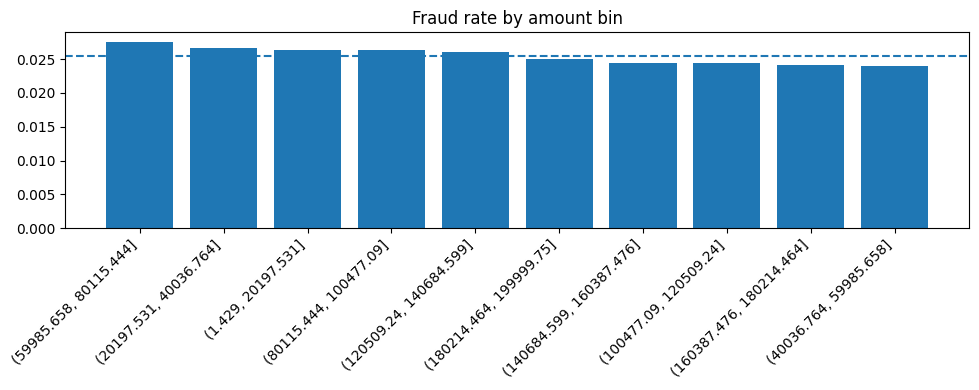


mcc_entropy_30d


,mcc_entropy_30d_bin,count,fraud_count,fraud_rate,lift
0,"(-0.001, 0.392]",10012,854,0.085298,3.346318
1,"(0.392, 0.791]",9996,613,0.061325,2.405827
2,"(0.791, 1.192]",10000,368,0.036800,1.443703
3,"(1.192, 1.592]",10003,221,0.022093,0.866747
4,"(1.592, 1.99]",9992,163,0.016313,0.639978
5,"(1.99, 2.398]",10011,98,0.009789,0.384042
8,"(3.197, 3.599]",10022,62,0.006186,0.242699
6,"(2.398, 2.795]",9988,61,0.006107,0.239597
9,"(3.599, 4.0]",9977,57,0.005713,0.224133
7,"(2.795, 3.197]",9999,52,0.005201,0.204022


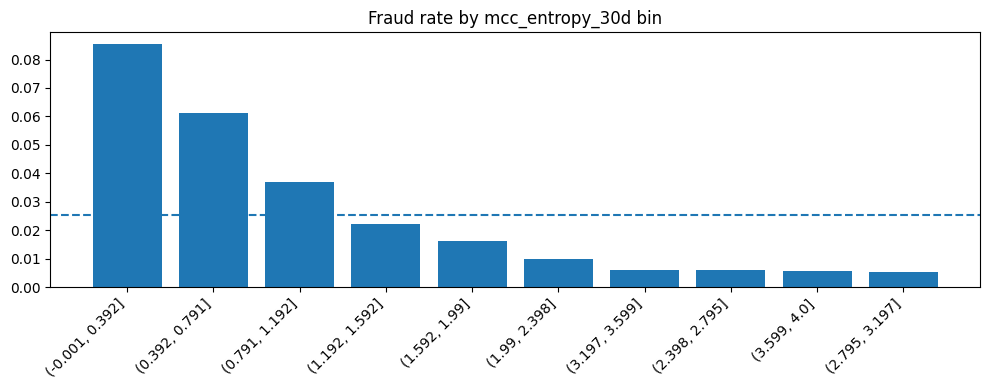


night_ratio_30d


,night_ratio_30d_bin,count,fraud_count,fraud_rate,lift
0,"(-0.001, 0.1]",10003,742,0.074178,2.910072
1,"(0.1, 0.2]",10018,504,0.050309,1.973693
2,"(0.2, 0.3]",10094,379,0.037547,1.473011
3,"(0.3, 0.399]",9921,309,0.031146,1.221893
4,"(0.399, 0.498]",10027,174,0.017353,0.680783
5,"(0.498, 0.599]",9942,134,0.013478,0.528763
6,"(0.599, 0.699]",9997,101,0.010103,0.396353
7,"(0.699, 0.799]",10072,88,0.008737,0.342766
8,"(0.799, 0.899]",9978,61,0.006113,0.239837
9,"(0.899, 1.0]",9948,57,0.005730,0.224786


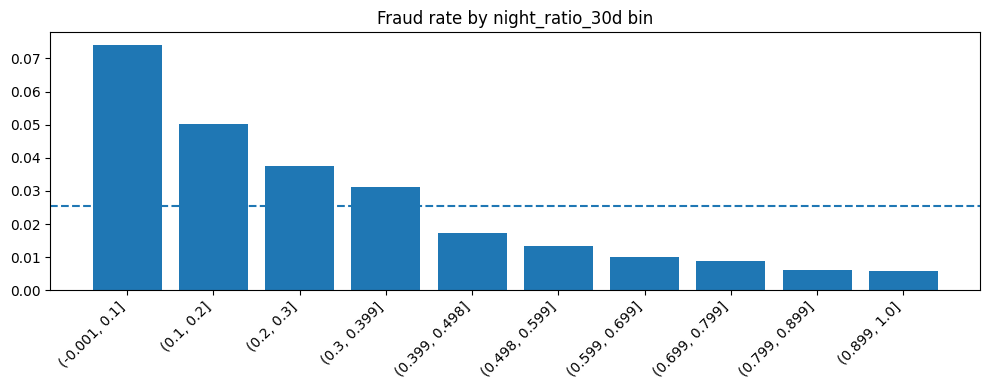


spending_trend


,spending_trend_bin,count,fraud_count,fraud_rate,lift
0,"(0.099, 0.59]",10020,666,0.066467,2.607574
1,"(0.59, 1.079]",9990,481,0.048148,1.888903
2,"(1.079, 1.566]",10009,353,0.035268,1.383612
3,"(1.566, 2.056]",9984,290,0.029046,1.139524
4,"(2.056, 2.54]",9997,221,0.022107,0.867267
5,"(2.54, 3.031]",10017,153,0.015274,0.599217
6,"(3.031, 3.523]",9992,115,0.011509,0.451519
7,"(3.523, 4.016]",10009,115,0.011490,0.450752
9,"(4.507, 5.0]",9981,81,0.008115,0.318377
8,"(4.016, 4.507]",10001,74,0.007399,0.290281


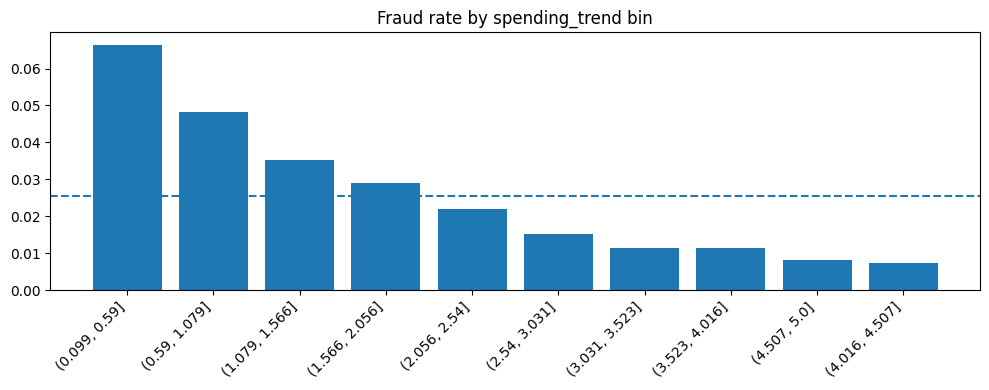


max_amount_30d


,max_amount_30d_bin,count,fraud_count,fraud_rate,lift
9,"(225071.135, 249999.11]",10000,663,0.0663,2.601020
8,"(200269.424, 225071.135]",10000,496,0.0496,1.945861
7,"(175314.076, 200269.424]",10000,349,0.0349,1.369164
6,"(150252.096, 175314.076]",10000,317,0.0317,1.243625
5,"(124744.115, 150252.096]",10000,202,0.0202,0.792468
4,"(99933.39, 124744.115]",10000,171,0.0171,0.670851
3,"(74690.599, 99933.39]",10000,117,0.0117,0.459004
2,"(49917.606, 74690.599]",10000,103,0.0103,0.404080
0,"(51.589000000000006, 24787.746]",10000,71,0.0071,0.278541
1,"(24787.746, 49917.606]",10000,60,0.0060,0.235386


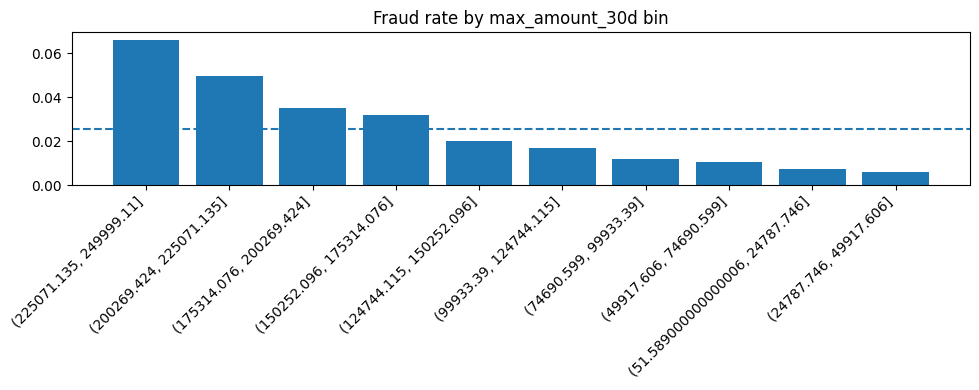


mean_amount_30d


,mean_amount_30d_bin,count,fraud_count,fraud_rate,lift
9,"(11.18, 97.99]",9990,321,0.032132,1.260578
7,"(7.84, 9.0]",9965,289,0.029002,1.137760
8,"(9.0, 11.18]",9986,282,0.028240,1.107867
6,"(7.09, 7.84]",9938,267,0.026867,1.054004
4,"(6.12, 6.55]",9894,247,0.024965,0.979389
5,"(6.55, 7.09]",9995,245,0.024512,0.961642
1,"(5.22, 5.47]",10049,239,0.023783,0.933051
3,"(5.76, 6.12]",10200,241,0.023627,0.926930
2,"(5.47, 5.76]",9816,213,0.021699,0.851285
0,"(4.999, 5.22]",10167,205,0.020163,0.791027


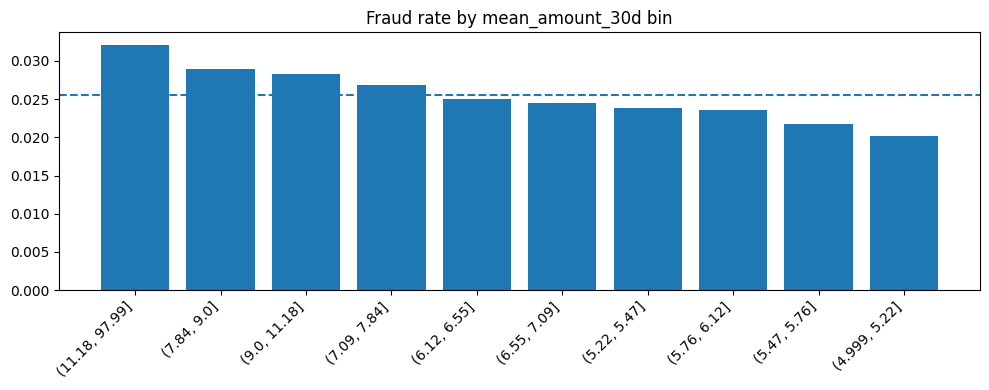


distinct_countries_30d


,distinct_countries_30d_bin,count,fraud_count,fraud_rate,lift
0,"(0.999, 3.0]",12114,748,0.061747,2.422391
1,"(3.0, 5.0]",7967,384,0.048199,1.890891
2,"(5.0, 8.0]",12022,426,0.035435,1.390154
3,"(8.0, 10.0]",7928,205,0.025858,1.014426
4,"(10.0, 13.0]",11942,231,0.019343,0.758866
5,"(13.0, 16.0]",12011,181,0.015070,0.591193
6,"(16.0, 18.0]",8054,104,0.012913,0.506584
8,"(21.0, 23.0]",8061,97,0.012033,0.472077
7,"(18.0, 21.0]",11953,116,0.009705,0.380725
9,"(23.0, 25.0]",7948,57,0.007172,0.281350


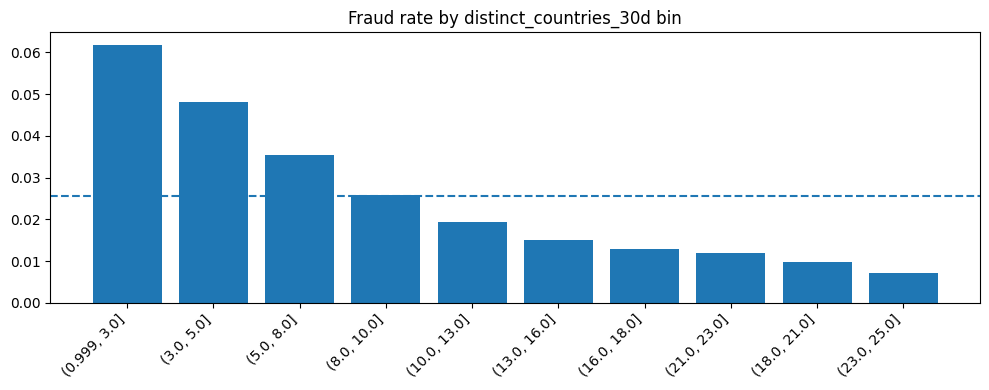


device_diversity_30d


,device_diversity_30d_bin,count,fraud_count,fraud_rate,lift
0,"(0.999, 5.0]",12509,474,0.037893,1.486572
1,"(5.0, 8.0]",7602,288,0.037885,1.486260
2,"(8.0, 12.0]",9903,306,0.030900,1.212229
3,"(12.0, 16.0]",10152,283,0.027876,1.093616
4,"(16.0, 20.0]",10049,251,0.024978,0.979898
5,"(20.0, 24.0]",9932,246,0.024768,0.971692
7,"(28.0, 33.0]",12424,244,0.019639,0.770475
6,"(24.0, 28.0]",9930,188,0.018933,0.742743
8,"(33.0, 36.0]",7583,120,0.015825,0.620827
9,"(36.0, 40.0]",9916,149,0.015026,0.589495


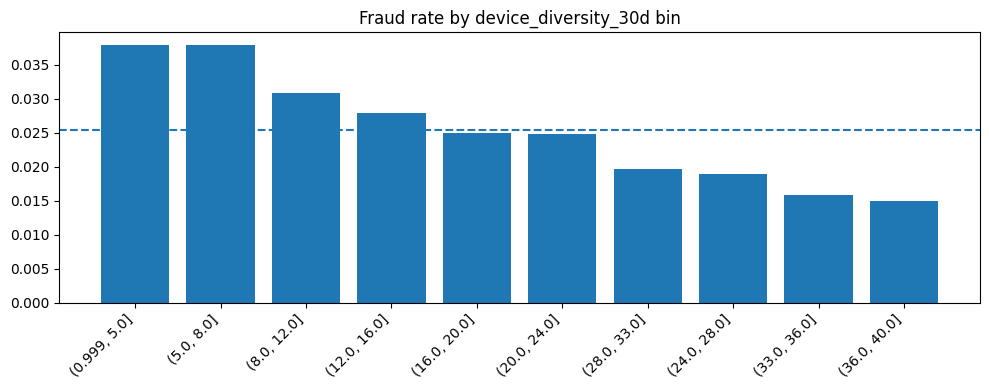


decline_rate_30d


,decline_rate_30d_bin,count,fraud_count,fraud_rate,lift
0,"(0.001, 0.067]",10322,426,0.041271,1.619108
1,"(0.067, 0.0918]",9678,339,0.035028,1.374182
2,"(0.0918, 0.113]",10353,318,0.030716,1.205011
3,"(0.113, 0.133]",9830,300,0.030519,1.197286
4,"(0.133, 0.154]",10056,253,0.025159,0.987019
5,"(0.154, 0.177]",10091,211,0.020910,0.820311
6,"(0.177, 0.202]",9691,198,0.020431,0.801543
7,"(0.202, 0.234]",10025,185,0.018454,0.723965
8,"(0.234, 0.283]",10025,176,0.017556,0.688745
9,"(0.283, 0.666]",9929,143,0.014402,0.565016


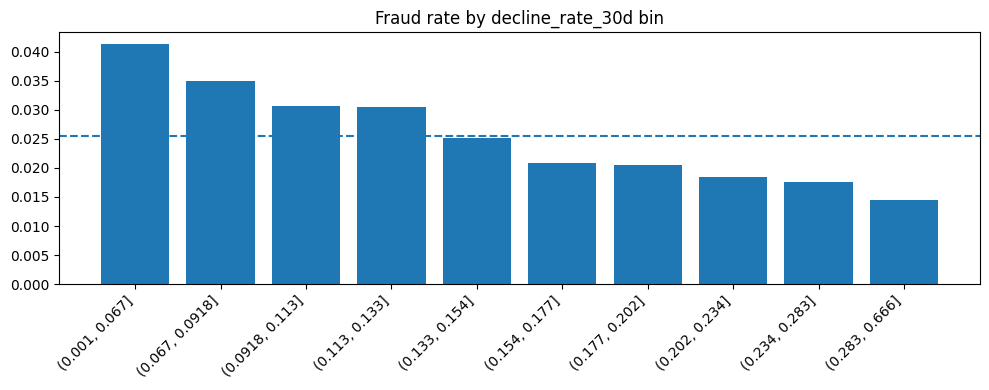


credit_util_today


,credit_util_today_bin,count,fraud_count,fraud_rate,lift
0,"(-0.001, 0.199]",10050,378,0.037612,1.475557
1,"(0.199, 0.398]",9993,353,0.035325,1.385827
2,"(0.398, 0.597]",9965,315,0.031611,1.240119
3,"(0.597, 0.798]",9995,295,0.029515,1.157896
4,"(0.798, 0.998]",10009,254,0.025377,0.995573
5,"(0.998, 1.197]",10020,239,0.023852,0.935751
6,"(1.197, 1.4]",10015,203,0.020270,0.795198
7,"(1.4, 1.598]",9990,194,0.019419,0.761845
8,"(1.598, 1.8]",10021,173,0.017264,0.677275
9,"(1.8, 2.0]",9942,145,0.014585,0.572169


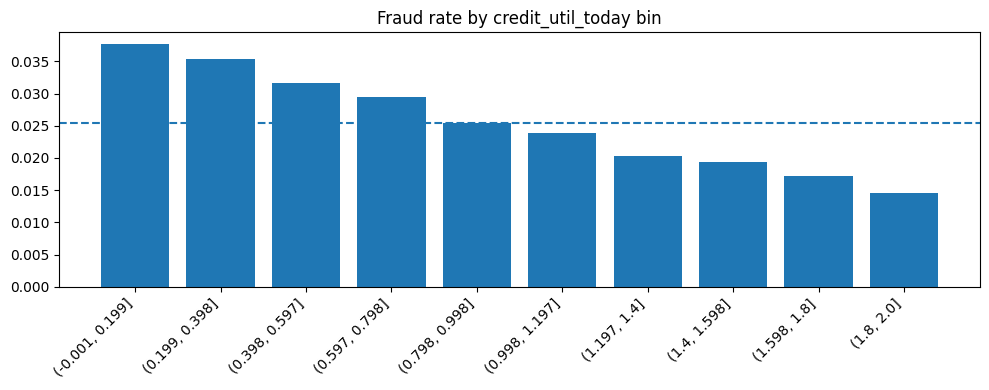


ip_score


,ip_score_bin,count,fraud_count,fraud_rate,lift
3,"(0.181, 0.223]",9988,269,0.026932,1.056584
2,"(0.14, 0.181]",9992,266,0.026621,1.044382
1,"(0.0922, 0.14]",10014,262,0.026163,1.026417
0,"(-0.00019999999999999998, 0.0922]",10006,260,0.025984,1.019396
7,"(0.361, 0.423]",10002,258,0.025795,1.011959
6,"(0.31, 0.361]",9996,250,0.025010,0.981169
5,"(0.265, 0.31]",9995,249,0.024912,0.977342
9,"(0.512, 0.911]",9999,247,0.024702,0.969104
8,"(0.423, 0.512]",9998,246,0.024605,0.965277
4,"(0.223, 0.265]",10010,242,0.024176,0.948443


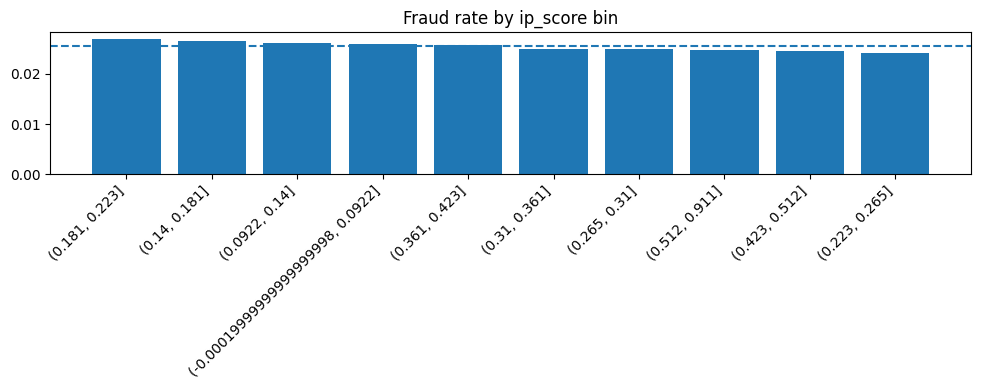


txn_count_7d


,txn_count_7d_bin,count,fraud_count,fraud_rate,lift
1,"(6.0, 14.0]",10118,278,0.027476,1.077905
7,"(64.0, 76.0]",10378,277,0.026691,1.047120
6,"(53.0, 64.0]",9839,257,0.026121,1.024737
3,"(23.0, 32.0]",9422,242,0.025685,1.007633
4,"(32.0, 43.0]",10850,276,0.025438,0.997952
2,"(14.0, 23.0]",10047,253,0.025182,0.987903
9,"(88.0, 100.0]",9654,241,0.024964,0.979354
0,"(-0.001, 6.0]",10435,258,0.024724,0.969968
8,"(76.0, 88.0]",9866,242,0.024529,0.962287
5,"(43.0, 53.0]",9391,225,0.023959,0.939942


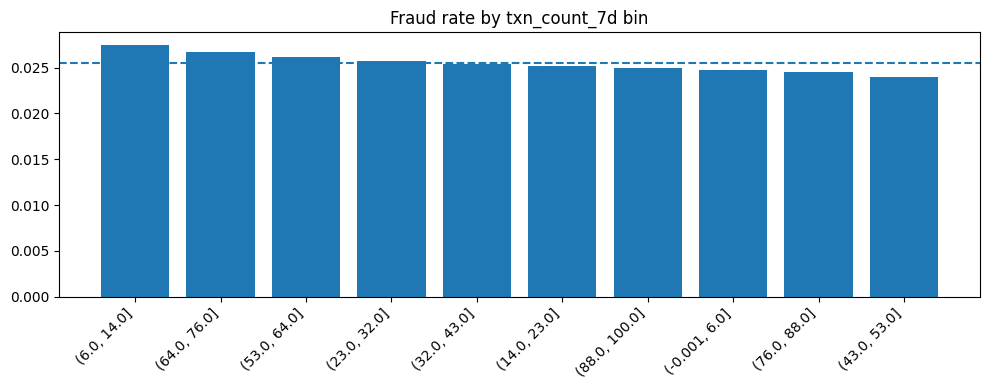


txn_count_30d


,txn_count_30d_bin,count,fraud_count,fraud_rate,lift
1,"(50.0, 100.0]",9968,269,0.026986,1.058704
0,"(0.999, 50.0]",10087,266,0.026371,1.034546
8,"(400.0, 450.0]",9950,261,0.026231,1.029076
2,"(100.0, 151.0]",10132,265,0.026155,1.026079
5,"(250.0, 300.0]",9995,254,0.025413,0.996968
9,"(450.0, 500.0]",9905,248,0.025038,0.982262
4,"(200.0, 250.0]",10011,249,0.024873,0.975780
6,"(300.0, 350.0]",10061,249,0.024749,0.970931
7,"(350.0, 400.0]",10038,247,0.024606,0.965339
3,"(151.0, 200.0]",9853,241,0.024460,0.959575


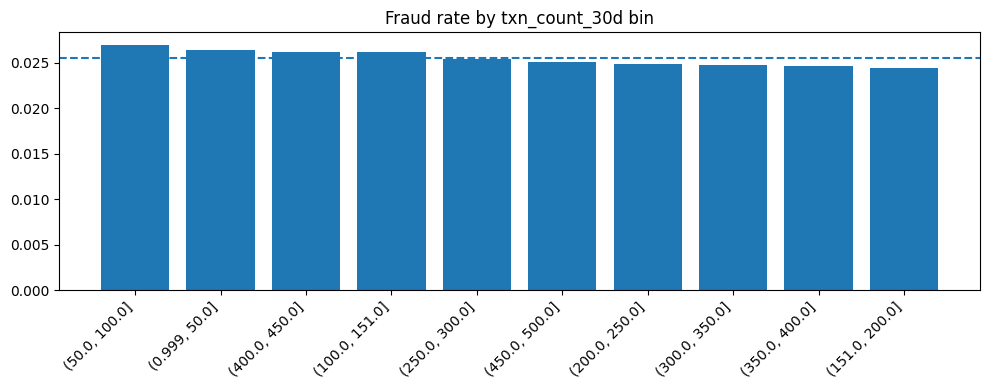

In [5]:
important_numeric = [
    "amount",
    "mcc_entropy_30d",
    "night_ratio_30d",
    "spending_trend",
    "max_amount_30d",
    "mean_amount_30d",
    "distinct_countries_30d",
    "device_diversity_30d",
    "decline_rate_30d",
    "credit_util_today",
    "ip_score",
    "txn_count_7d",
    "txn_count_30d",
]

for col in important_numeric:
    if col in df.columns:
        print("\n" + "=" * 100)
        print(col)
        table = numeric_bin_fraud_rate(df, col, target_col=TARGET_COL, q=10)
        display(table)

        if not table.empty:
            plt.figure(figsize=(10, 4))
            plt.bar(table[f"{col}_bin"].astype(str), table["fraud_rate"])
            plt.axhline(BASE_FRAUD_RATE, linestyle="--")
            plt.title(f"Fraud rate by {col} bin")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

In [6]:
INSIGHT_DIR = REPORT_DIR / "insights"

if INSIGHT_DIR.exists():
    for file in sorted(INSIGHT_DIR.glob("*.csv")):
        print("\n" + "=" * 100)
        print(file.name)
        display(pd.read_csv(file).head(20))
else:
    print("Chưa có data/reports/insights")


actionable_rules_train.csv


,rule,support,support_rate,fraud_count,fraud_rate,global_fraud_rate,fraud_rate_diff,lift,order,strength,business_interpretation,feature_a,value_a,feature_b,value_b
0,low_night_ratio_flag AND low_mcc_entropy_x_car...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,2,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
1,card_not_present_flag AND low_mcc_entropy_x_lo...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,2,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
2,low_mcc_entropy_x_low_night_ratio AND low_mcc_...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,2,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
3,low_mcc_entropy_flag AND low_night_ratio_flag ...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,3,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
4,low_mcc_entropy_flag AND low_night_ratio_flag ...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,3,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
5,low_mcc_entropy_flag AND card_not_present_flag...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,3,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
6,low_mcc_entropy_flag AND low_mcc_entropy_x_low...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,3,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
7,low_night_ratio_flag AND card_not_present_flag...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,3,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
8,low_night_ratio_flag AND card_not_present_flag...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,3,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN
9,low_night_ratio_flag AND low_mcc_entropy_x_low...,479,0.006843,128,0.267223,0.025471,0.241752,10.491103,3,VERY_STRONG,User có lịch sử ngành hàng ít đa dạng và ít gi...,NaN,NaN,NaN,NaN



boolean_interaction_stability.csv


,rule,support_train,fraud_count_train,fraud_rate_train,global_fraud_rate_train,fraud_rate_diff_train,lift_train,support_valid,fraud_count_valid,fraud_rate_valid,global_fraud_rate_valid,fraud_rate_diff_valid,lift_valid,lift_diff_valid_train,lift_ratio_valid_train,fraud_rate_diff_valid_train
0,high_max_amount_30d_flag AND low_country_diver...,354,58,0.163842,0.025471,0.138370,6.432376,83,23,0.277108,0.0252,0.251908,10.996366,4.563990,1.709534,0.113267
1,low_night_ratio_flag AND low_mcc_entropy_x_car...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
2,card_not_present_flag AND low_mcc_entropy_x_lo...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
3,low_mcc_entropy_x_low_night_ratio AND low_mcc_...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
4,low_mcc_entropy_flag AND low_night_ratio_flag ...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
5,low_mcc_entropy_flag AND low_night_ratio_flag ...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
6,low_mcc_entropy_flag AND card_not_present_flag...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
7,low_mcc_entropy_flag AND low_mcc_entropy_x_low...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
8,low_night_ratio_flag AND card_not_present_flag...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266
9,low_night_ratio_flag AND card_not_present_flag...,479,128,0.267223,0.025471,0.241752,10.491103,94,25,0.265957,0.0252,0.240757,10.553867,0.062764,1.005983,-0.001266



boolean_interactions_train.csv


...

,amount,currency,local_timestamp,payment_channel,merchant_country,mcc,card_present,ip_risk,device_id,card_entry_mode,auth_result,merchant_id,pin_verif_method,tokenised,recurring_flag,cross_border,card_activation_age,auth_characteristics,message_type,mean_amount_30d,std_amount_30d,max_amount_30d,txn_counts,distinct_merchants_7d,distinct_countries_30d,online_share_7d,night_ratio_30d,days_since_last_txn,decline_rate_30d,chargebacks_365d,device_diversity_30d,mcc_entropy_30d,credit_util_today,spending_trend,term_location,fraud,ip_address,ip_score,txn_count_7d,txn_count_30d,txn_count_ratio_7d_30d,ip_is_private,ip_score_bin,transaction_datetime,hour,day_of_week,day_name,is_weekend,is_night_txn,month,day,year,time_period,night_unusual_score,is_night_unusual,amount_invalid_flag,std_amount_30d_zero_flag,mean_amount_30d_zero_flag,duplicate_row_flag,ip_score_risk_group,decline_rate_risk_group,credit_util_risk_group,txn_count_7d_group,txn_velocity_group,night_ratio_group,amount_to_mean_30d,amount_to_mean_group,amount_to_max_30d,amount_to_max_group,low_mcc_entropy_flag,low_night_ratio_flag,high_max_amount_30d_flag,low_spending_trend_flag,low_country_diversity_flag,high_device_diversity_flag,high_decline_rate_flag,high_ip_score_flag,night_transaction_flag,card_not_present_flag,cross_border_flag,tokenised_flag,night_unusual_group,high_ip_high_amount_flag,high_decline_high_amount_flag,private_ip_high_score_flag,high_velocity_high_amount_flag,low_mcc_entropy_x_low_night_ratio,low_mcc_entropy_x_high_max_amount_30d,low_mcc_entropy_x_low_spending_trend,low_mcc_entropy_x_card_not_present,low_night_ratio_x_high_max_amount_30d,cross_border_x_low_country_diversity,high_ip_score_x_card_not_present
0,71385.62,GBP,2025-03-07 07:19:19,MOBILE_APP,PH,7765,False,"{'ip': '174.77.134.216', 'score': 0.3064}",DEV-5C528B7234584CFE,CONTACTLESS,CVV_PASS,MID-5BA3C327F75C,NONE,False,MOTO_MAIL,False,3986,CRYPTOGRAM_PRESENT,0200-FinReq,6.75,1.40,212755.87,"(48, 69)",21,10,0.220,0.760,65,0.282,0,32,2.124,1.452,4.548,CALL_CENTER,0,174.77.134.216,0.3064,48.0,69.0,0.685714,0,medium,2025-03-07 07:19:19,7,4,Friday,0,0,3,7,2025,morning,0.0,0,0,0,0,0,medium,medium,very_high,gt_20,medium,high,9211.047742,extreme,0.335527,below_half_max,0,0,0,0,0,0,0,0,0,1,0,0,not_night,0,0,0,0,0,0,0,0,0,0,0
1,41958.74,EUR,2025-03-07 07:19:30,API_SERVER,IN,7995,True,"{'ip': '231.148.136.200', 'score': 0.4186}",DEV-F5CB0AA260AF42F8,TOKEN_IN_APP,3DS_PASS,MID-36FC92EFCEE0,SIGNATURE,True,MOTO_PHONE,True,3804,CRYPTOGRAM_PRESENT,0200-FinReq,12.94,1.97,230333.61,"(11, 13)",120,20,0.135,0.236,30,0.095,0,24,1.742,0.328,4.655,ONLINE_PORTAL,0,231.148.136.200,0.4186,11.0,13.0,0.785714,0,medium,2025-03-07 07:19:30,7,4,Friday,0,0,3,7,2025,morning,0.0,0,0,0,0,0,medium,low,medium,11_20,medium,low,3009.952654,extreme,0.182164,below_half_max,0,0,1,0,0,0,0,0,0,0,1,1,not_night,0,0,0,0,0,0,0,0,0,0,0
2,153871.73,USD,2025-03-07 07:21:59,WEB_BROWSER,ZA,3038,False,"{'ip': '77.110.52.227', 'score': 0.171}",DEV-176EDAC722944DBA,CONTACTLESS,3DS_FAIL,MID-06909B008FFA,ONLINE_PIN,False,RECURRING_SUBSCRIPTION,False,2234,CRYPTOGRAM_PRESENT,0400-Reversal,5.31,1.18,141022.77,"(72, 156)",1,5,0.083,0.099,89,0.101,0,3,2.480,1.486,3.255,WEARABLE_PAY,0,77.110.52.227,0.1710,72.0,156.0,0.458599,0,low,2025-03-07 07:21:59,7,4,Friday,0,0,3,7,2025,morning,0.0,0,0,0,0,0,low,medium,very_high,gt_20,low,very_low,24385.377179,extreme,1.091105,above_max,0,1,0,0,0,0,0,0,0,1,0,0,not_night,0,0,0,0,0,0,0,0,0,0,0
3,12640.64,EUR,2025-03-07 07:22:41,WEB_BROWSER,PH,4561,False,"{'ip': '29.204.33.254', 'score': 0.4649}",DEV-43083AB6E205477A,CHIP,3DS_FAIL,MID-0470B187B553,ONLINE_PIN,False,RECURRING_SUBSCRIPTION,True,554,CARD_PRESENT,0500-Advice,7.09,2.62,162129.41,"(97, 373)",64,3,0.635,0.301,29,0.312,0,12,0.811,1.370,3.559,MOBILE_APP,0,29.204.33.254,0.4649,97.0,373.0,0.259358,0,medium,2025-03-07 07:22:41,7,4,Friday,0,0,3,7,2025,morning,0.0,0,0,0,0,0,medium,high,very_high,gt_20,low,medium,1562.501854,extreme,0.077966,below_half_max,0,0,0,0,1,0,1,0,0,1,1,0,n


train_valid_global_fraud_rate.csv


,split,fraud_rate,used_min_count
0,train,0.025471,350
1,validation,0.025200,75



validation_features_preview.csv


,amount,currency,local_timestamp,payment_channel,merchant_country,mcc,card_present,ip_risk,device_id,card_entry_mode,auth_result,merchant_id,pin_verif_method,tokenised,recurring_flag,cross_border,card_activation_age,auth_characteristics,message_type,mean_amount_30d,std_amount_30d,max_amount_30d,txn_counts,distinct_merchants_7d,distinct_countries_30d,online_share_7d,night_ratio_30d,days_since_last_txn,decline_rate_30d,chargebacks_365d,device_diversity_30d,mcc_entropy_30d,credit_util_today,spending_trend,term_location,fraud,ip_address,ip_score,txn_count_7d,txn_count_30d,txn_count_ratio_7d_30d,ip_is_private,ip_score_bin,transaction_datetime,hour,day_of_week,day_name,is_weekend,is_night_txn,month,day,year,time_period,night_unusual_score,is_night_unusual,amount_invalid_flag,std_amount_30d_zero_flag,mean_amount_30d_zero_flag,duplicate_row_flag,ip_score_risk_group,decline_rate_risk_group,credit_util_risk_group,txn_count_7d_group,txn_velocity_group,night_ratio_group,amount_to_mean_30d,amount_to_mean_group,amount_to_max_30d,amount_to_max_group,low_mcc_entropy_flag,low_night_ratio_flag,high_max_amount_30d_flag,low_spending_trend_flag,low_country_diversity_flag,high_device_diversity_flag,high_decline_rate_flag,high_ip_score_flag,night_transaction_flag,card_not_present_flag,cross_border_flag,tokenised_flag,night_unusual_group,high_ip_high_amount_flag,high_decline_high_amount_flag,private_ip_high_score_flag,high_velocity_high_amount_flag,low_mcc_entropy_x_low_night_ratio,low_mcc_entropy_x_high_max_amount_30d,low_mcc_entropy_x_low_spending_trend,low_mcc_entropy_x_card_not_present,low_night_ratio_x_high_max_amount_30d,cross_border_x_low_country_diversity,high_ip_score_x_card_not_present
0,28510.54,USD,2025-05-09 08:46:31,IVR_PHONE,ZA,3005,True,"{'ip': '4.152.77.208', 'score': 0.2561}",DEV-9586CAB37E184FCA,MAGSTRIPE,3DS_FAIL,MID-00F6D25D00AF,ONLINE_PIN,False,RECURRING_SUBSCRIPTION,False,4343,E_COMMERCE,0510-AdviceRsp,6.92,2.20,44884.36,"(22, 417)",93,21,0.851,0.314,154,0.125,0,33,1.415,0.878,1.743,POS_TERMINAL,0,4.152.77.208,0.2561,22.0,417.0,0.052632,0,medium,2025-05-09 08:46:31,8,4,Friday,0,0,5,9,2025,morning,0.0,0,0,0,0,0,medium,medium,high,gt_20,very_low,medium,3599.815657,extreme,0.635186,near_max,0,0,0,0,0,0,0,0,0,0,0,0,not_night,0,0,0,0,0,0,0,0,0,0,0
1,197532.73,USD,2025-05-09 08:46:49,SMART_WATCH,FR,7143,False,"{'ip': '170.94.54.13', 'score': 0.2408}",DEV-09F35D69B51A4FC8,MANUAL_KEYED,CVV_FAIL,MID-8A6B88CFBE24,NONE,True,INSTALLMENT_PLAN,False,3183,CARD_PRESENT,0200-FinReq,7.41,5.03,209513.70,"(37, 209)",80,9,0.665,0.823,49,0.014,0,26,2.780,0.170,0.172,BRANCH_COUNTER,0,170.94.54.13,0.2408,37.0,209.0,0.176190,0,medium,2025-05-09 08:46:49,8,4,Friday,0,0,5,9,2025,morning,0.0,0,0,0,0,0,medium,low,low,gt_20,very_low,high,23487.839477,extreme,0.942811,near_max,0,0,0,1,0,0,0,0,0,1,0,1,not_night,0,0,0,0,0,0,0,0,0,0,0
2,123399.74,USD,2025-05-09 08:47:07,SMART_WATCH,AU,3123,False,"{'ip': '133.178.205.107', 'score': 0.2424}",DEV-9C565A2F32C245DA,TOKEN_IN_APP,3DS_PASS,MID-10DDBBCB727D,NONE,True,SINGLE_PURCHASE,False,1099,FALLBACK_MAG,0200-FinReq,6.46,1.67,156270.85,"(85, 150)",78,22,0.378,0.181,154,0.324,0,38,3.074,1.044,1.535,ONLINE_PORTAL,0,133.178.205.107,0.2424,85.0,150.0,0.562914,0,medium,2025-05-09 08:47:07,8,4,Friday,0,0,5,9,2025,morning,0.0,0,0,0,0,0,medium,high,very_high,gt_20,medium,low,16541.520107,extreme,0.789648,near_max,0,0,0,0,0,1,1,0,0,1,0,1,not_night,0,0,0,0,0,0,0,0,0,0,0
3,29240.10,EUR,2025-05-09 08:47:17,WEB_BROWSER,ID,4765,False,"{'ip': '217.45.252.53', 'score': 0.1817}",DEV-5FEAB0207D604697,MANUAL_KEYED,BIOMETRIC_PASS,MID-4BE12C8042A0,SIGNATURE,True,MOTO_MAIL,False,1735,E_COMMERCE,0110-AuthRsp,10.58,1.64,222580.47,"(97, 125)",30,8,0.611,0.762,61,0.133,0,17,2.258,0.542,2.029,WEARABLE_PAY,0,217.45.252.53,0.1817,97.0,125.0,0.769841,0,low,2025-05-09 08:47:17,8,4,Friday,0,0,5,9,2025,morning,0.0,0,0,0,0,0,low,medium,medium,gt_20,medium,high,2525.051813,extreme,0.131368,below_half_max,0,0,0,0,0,0,0,0,0,1,0,1,not_night,0,0,0,0,0,0,0,

## Kết luận cần ghi sau khi chạy

            - Category/bin nào có lift cao?
            - Numeric nào có fraud rate khác biệt rõ?
            - Insight nào nên kiểm tra stability trên train/validation?